In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

# ── scikit-learn ──────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

In [ ]:
FILE = "Flipcart.xlsx"

customers    = pd.read_excel(FILE, sheet_name="customers",     parse_dates=["JoinDate"])
orders       = pd.read_excel(FILE, sheet_name="orders",        parse_dates=["OrderDate"])
order_details= pd.read_excel(FILE, sheet_name="order_details")
products     = pd.read_excel(FILE, sheet_name="products")
events       = pd.read_excel(FILE, sheet_name="events",        parse_dates=["EventTime"])

print("✅ Data loaded successfully")
print(f"   Customers: {len(customers):,} | Orders: {len(orders):,} | Events: {len(events):,} | Order_Details: {len(order_details):,} | Products: {len(products):,}")

✅ Data loaded successfully
   Customers: 500 | Orders: 3,000 | Events: 5,000 | Order_Details: 3,000 | Products: 200


In [ ]:
# 1. FEATURE ENGINEERING — RFM + BEHAVIORAL SIGNALS
# ═══════════════════════════════════════════════════════
SNAPSHOT_DATE = orders["OrderDate"].max() + timedelta(days=1)
CHURN_DAYS    = 90   # threshold: no order in 90 days = churned

In [ ]:
# ── Order-level revenue ───────────────────────────────
order_revenue = (
    order_details
    .assign(LineRevenue=lambda d: d["Quantity"] * d["UnitPrice"])
    .groupby("OrderID")["LineRevenue"].sum()
    .reset_index()
)
orders_full = orders.merge(order_revenue, on="OrderID", how="left")

In [ ]:
# ── RFM per customer ─────────────────────────────────
rfm = (
    orders_full
    .groupby("CustomerID")
    .agg(
        Recency  =("OrderDate",    lambda x: (SNAPSHOT_DATE - x.max()).days),
        Frequency=("OrderID",      "count"),
        Monetary =("LineRevenue",  "sum"),
        LastOrder=("OrderDate",    "max")
    )
    .reset_index()
)


In [ ]:
rfm

,CustomerID,Recency,Frequency,Monetary,LastOrder
0,1,5,6,293673,2025-11-28
1,2,25,6,175899,2025-11-08
2,3,62,4,189297,2025-10-02
3,4,281,2,119091,2025-02-25
4,5,141,7,201634,2025-07-15
...,...,...,...,...,...
493,496,56,2,50021,2025-10-08
494,497,404,7,87850,2024-10-25
495,498,1,5,321506,2025-12-02
496,499,79,5,220995,2025-09-15


In [ ]:
# ── Churn label ───────────────────────────────────────
rfm["Churned"] = (rfm["Recency"] >= CHURN_DAYS).astype(int)

In [ ]:
rfm["Churned"]

,Churned
0,0
1,0
2,0
3,1
4,1
...,...
493,0
494,1
495,0
496,0


In [ ]:
# ── Behavioral features from events ──────────────────
event_feats = (
    events
    .groupby(["CustomerID", "EventType"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
    .rename(columns={"View": "ViewCount", "AddToCart": "CartCount", "Purchase": "PurchaseCount"})
)
for col in ["ViewCount", "CartCount", "PurchaseCount"]:
    if col not in event_feats.columns:
        event_feats[col] = 0

event_feats["CartToViewRatio"] = (
    event_feats["CartCount"] / (event_feats["ViewCount"] + 1)
)


In [ ]:
event_feats

EventType,CustomerID,CartCount,PurchaseCount,ViewCount,CartToViewRatio
0,1,2,2,6,0.285714
1,2,2,3,3,0.500000
2,3,6,4,2,2.000000
3,4,3,6,5,0.500000
4,5,2,1,2,0.666667
...,...,...,...,...,...
495,496,4,5,4,0.800000
496,497,2,1,1,1.000000
497,498,3,3,7,0.375000
498,499,5,2,5,0.833333


In [ ]:
# ── Category preference (most purchased category) ────
order_cat = (
    order_details
    .merge(orders[["OrderID", "CustomerID"]], on="OrderID")
    .merge(products[["ProductID", "Category"]], on="ProductID")
    .groupby(["CustomerID", "Category"])["OrderDetailID"]
    .count()
    .reset_index()
    .sort_values("OrderDetailID", ascending=False)
    .drop_duplicates("CustomerID")
    [["CustomerID", "Category"]]
    .rename(columns={"Category": "TopCategory"})
)


In [ ]:
order_cat

,CustomerID,TopCategory
458,119,Home
1628,409,Books
1835,459,Mobiles
659,168,Grocery
302,80,Books
...,...,...
1912,477,Sports
1939,484,Sports
45,11,Sports
1983,496,Sports


In [ ]:
# ── Payment method preference ─────────────────────────
pay_pref = (
    orders
    .groupby(["CustomerID", "PaymentMethod"])["OrderID"]
    .count()
    .reset_index()
    .sort_values("OrderID", ascending=False)
    .drop_duplicates("CustomerID")
    [["CustomerID", "PaymentMethod"]]
    .rename(columns={"PaymentMethod": "PrefPayment"})
)

In [ ]:
pay_pref

,CustomerID,PrefPayment
1526,487,UPI
828,264,NetBanking
1478,473,NetBanking
918,292,Card
1066,339,COD
...,...,...
118,38,UPI
1465,469,NetBanking
107,35,UPI
1493,477,UPI


In [ ]:
# ── Merge all features ────────────────────────────────
df = (
    rfm
    .merge(customers[["CustomerID", "State"]], on="CustomerID", how="left")
    .merge(event_feats[["CustomerID","ViewCount","CartCount","PurchaseCount","CartToViewRatio"]], on="CustomerID", how="left")
    .merge(order_cat,  on="CustomerID", how="left")
    .merge(pay_pref,   on="CustomerID", how="left")
    .fillna({"ViewCount": 0, "CartCount": 0, "PurchaseCount": 0, "CartToViewRatio": 0})
)

In [ ]:
df

,CustomerID,Recency,Frequency,Monetary,LastOrder,Churned,State,ViewCount,CartCount,PurchaseCount,CartToViewRatio,TopCategory,PrefPayment
0,1,5,6,293673,2025-11-28,0,Bihar,6,2,2,0.285714,Grocery,UPI
1,2,25,6,175899,2025-11-08,0,Kerala,3,2,3,0.500000,Mobiles,NetBanking
2,3,62,4,189297,2025-10-02,0,Telangana,2,6,4,2.000000,Mobiles,COD
3,4,281,2,119091,2025-02-25,1,Uttar Pradesh,5,3,6,0.500000,Home,COD
4,5,141,7,201634,2025-07-15,1,Goa,2,2,1,0.666667,Fashion,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...
493,496,56,2,50021,2025-10-08,0,Punjab,4,4,5,0.800000,Sports,Card
494,497,404,7,87850,2024-10-25,1,Chhattisgarh,1,2,1,1.000000,Electronics,NetBanking
495,498,1,5,321506,2025-12-02,0,Telangana,7,3,3,0.375000,Books,UPI
496,499,79,5,220995,2025-09-15,0,Gujarat,5,5,2,0.833333,Electronics,NetBanking


In [ ]:
# ── Encode categoricals ───────────────────────────────
le = LabelEncoder()
for col in ["State", "TopCategory", "PrefPayment"]:
    df[col + "_enc"] = le.fit_transform(df[col].fillna("Unknown"))

print(f"\n✅ Features engineered | Shape: {df.shape}")
print(f"   Churn rate: {df['Churned'].mean()*100:.1f}%  "
      f"({df['Churned'].sum()} churned / {len(df)} total)")



✅ Features engineered | Shape: (498, 16)
   Churn rate: 48.2%  (240 churned / 498 total)


In [ ]:
# ═══════════════════════════════════════════════════════
# 2. RFM SEGMENTATION (MARKETING PERSONAS)
# ═══════════════════════════════════════════════════════
def rfm_segment(row):
    r, f, m = row["Recency"], row["Frequency"], row["Monetary"]
    if r < 30 and f >= 5 and m > 50000:
        return "Champions"
    elif r < 60 and f >= 3:
        return "Loyal Customers"
    elif r < 30 and f <= 2:
        return "New Customers"
    elif 60 <= r < 120 and f >= 3:
        return "At Risk"
    elif r >= 120 and f >= 2:
        return "Lost"
    else:
        return "Potential Loyalist"
df["RFM_Segment"] = df.apply(rfm_segment, axis=1)
print("\n✅ RFM Segments:")
print(df["RFM_Segment"].value_counts().to_string())


✅ RFM Segments:
RFM_Segment
Lost                  193
Loyal Customers       103
Champions             101
At Risk                88
Potential Loyalist     12
New Customers           1


In [ ]:
# ═══════════════════════════════════════════════════════
# 3. MODEL TRAINING
# ═══════════════════════════════════════════════════════
FEATURES = [
    "Recency", "Frequency", "Monetary",
    "ViewCount", "CartCount", "PurchaseCount", "CartToViewRatio",
    "State_enc", "TopCategory_enc", "PrefPayment_enc"
]
TARGET = "Churned"

X = df[FEATURES].fillna(0)
y = df[TARGET]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


In [ ]:
models = {
    "Logistic Regression":  LogisticRegression(max_iter=500, random_state=42),
    "Random Forest":        RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting":    GradientBoostingClassifier(n_estimators=100, random_state=42),
}
results = {}
print("\n✅ Model comparison:")


✅ Model comparison:


In [ ]:
for name, model in models.items():
    Xs = X_train_s if name == "Logistic Regression" else X_train
    model.fit(Xs, y_train)
    Xts = X_test_s if name == "Logistic Regression" else X_test
    proba = model.predict_proba(Xts)[:, 1]
    auc   = roc_auc_score(y_test, proba)
    cv    = cross_val_score(model, X if name != "Logistic Regression" else scaler.transform(X),
                            y, cv=5, scoring="roc_auc").mean()
    results[name] = {"model": model, "proba_test": proba, "auc": auc, "cv_auc": cv}
    print(f"   {name:<25} AUC={auc:.3f}  CV-AUC={cv:.3f}")

best_name = max(results, key=lambda k: results[k]["auc"])
best      = results[best_name]
print(f"\n   🏆 Best model: {best_name}")

   Logistic Regression       AUC=0.998  CV-AUC=0.999
   Random Forest             AUC=1.000  CV-AUC=1.000
   Gradient Boosting         AUC=1.000  CV-AUC=1.000

   🏆 Best model: Random Forest


In [ ]:
# ── Churn scores for all customers ───────────────────
Xall   = scaler.transform(X) if best_name == "Logistic Regression" else X
df["ChurnProbability"] = best["model"].predict_proba(Xall)[:, 1]
df["ChurnRisk"]        = pd.cut(
    df["ChurnProbability"],
    bins=[0, 0.3, 0.6, 1.0],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)


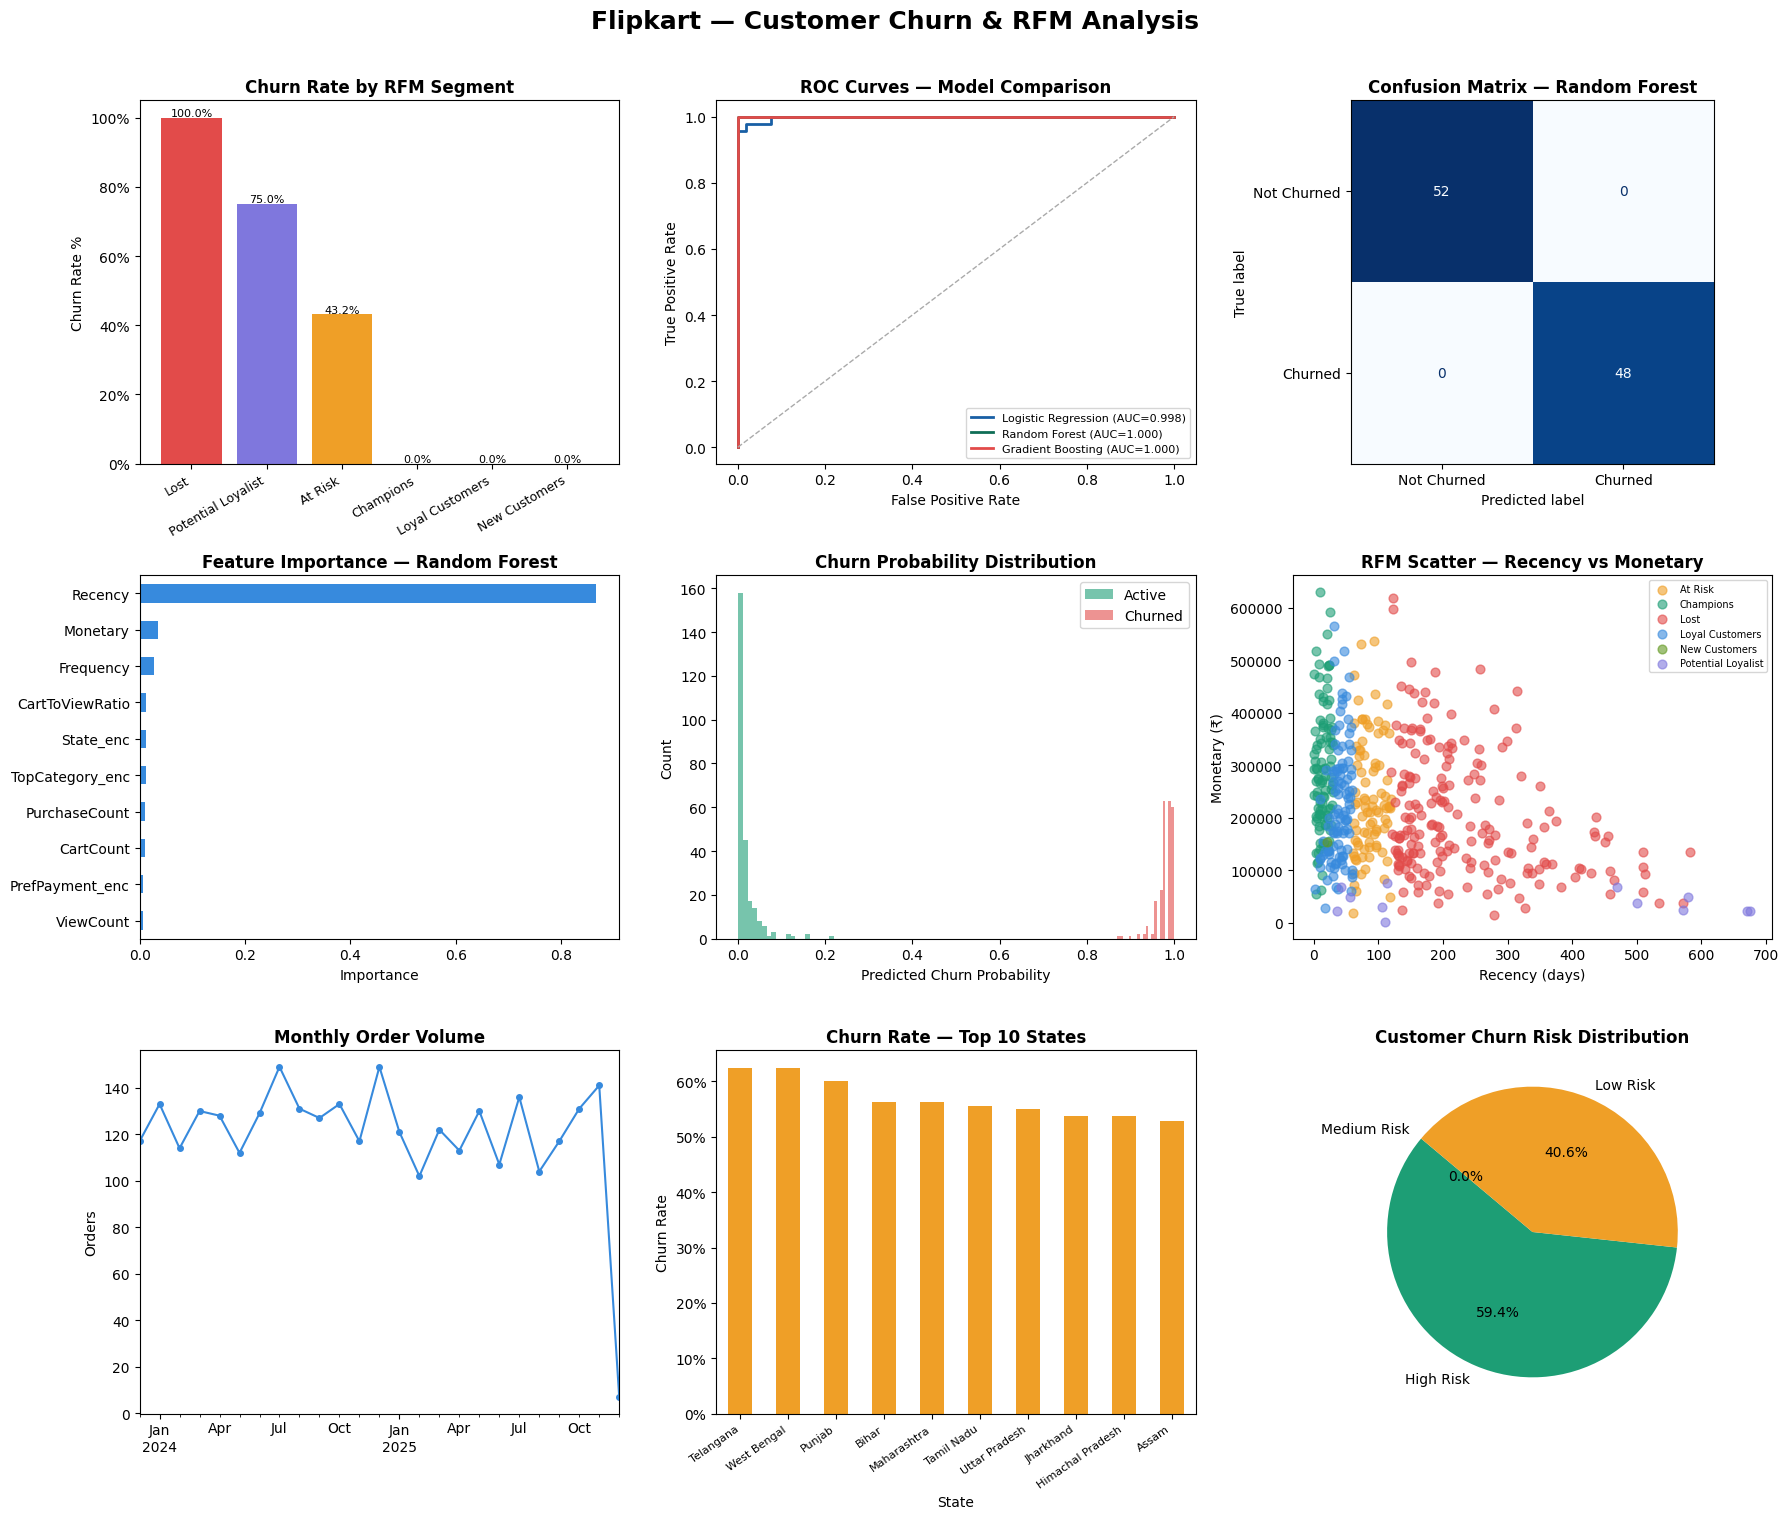

In [ ]:
# ═══════════════════════════════════════════════════════
# 4. VISUALISATIONS
# ═══════════════════════════════════════════════════════
palette = {"Champions":"#1D9E75","Loyal Customers":"#378ADD",
           "New Customers":"#639922","At Risk":"#EF9F27",
           "Lost":"#E24B4A","Potential Loyalist":"#7F77DD"}

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle("Flipkart — Customer Churn & RFM Analysis", fontsize=18, fontweight="bold", y=1.01)


# ── 1. Churn rate by RFM segment ──────────────────────
ax = axes[0, 0]
seg_churn = df.groupby("RFM_Segment")["Churned"].mean().sort_values(ascending=False)
bars = ax.bar(seg_churn.index, seg_churn.values * 100,
              color=[palette.get(s, "#888") for s in seg_churn.index])
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Churn Rate by RFM Segment", fontweight="bold")
ax.set_xticklabels(seg_churn.index, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Churn Rate %")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
            f"{b.get_height():.1f}%", ha="center", fontsize=8)

# ── 2. ROC curves all models ──────────────────────────
ax = axes[0, 1]
colors = ["#185FA5", "#0F6E56", "#E24B4A"]
for (name, res), col in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res["proba_test"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})", color=col, lw=2)
ax.plot([0,1],[0,1],"--", color="#aaa", lw=1)
ax.set_title("ROC Curves — Model Comparison", fontweight="bold")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=8)

# ── 3. Confusion matrix (best model) ─────────────────
ax = axes[0, 2]
y_pred = best["model"].predict(X_test_s if best_name=="Logistic Regression" else X_test)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Not Churned","Churned"]).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix — {best_name}", fontweight="bold")

# ── 4. Feature importance (best tree model) ──────────
ax = axes[1, 0]
tree_model_name = "Random Forest" if "Random Forest" in results else "Gradient Boosting"
tm = results[tree_model_name]["model"]
fi = pd.Series(tm.feature_importances_, index=FEATURES).sort_values(ascending=True)
fi.plot(kind="barh", ax=ax, color="#378ADD")
ax.set_title(f"Feature Importance — {tree_model_name}", fontweight="bold")
ax.set_xlabel("Importance")

# ── 5. Churn probability distribution ────────────────
ax = axes[1, 1]
ax.hist(df.loc[df["Churned"]==0, "ChurnProbability"], bins=20,
        alpha=0.6, color="#1D9E75", label="Active")
ax.hist(df.loc[df["Churned"]==1, "ChurnProbability"], bins=20,
        alpha=0.6, color="#E24B4A", label="Churned")
ax.set_title("Churn Probability Distribution", fontweight="bold")
ax.set_xlabel("Predicted Churn Probability"); ax.set_ylabel("Count")
ax.legend()

# ── 6. RFM scatter — Recency vs Monetary ─────────────
ax = axes[1, 2]
for seg, grp in df.groupby("RFM_Segment"):
    ax.scatter(grp["Recency"], grp["Monetary"],
               label=seg, alpha=0.6, s=40, color=palette.get(seg,"#888"))
ax.set_title("RFM Scatter — Recency vs Monetary", fontweight="bold")
ax.set_xlabel("Recency (days)"); ax.set_ylabel("Monetary (₹)")
ax.legend(fontsize=7)

# ── 7. Monthly order trend ────────────────────────────
ax = axes[2, 0]
orders_monthly = (
    orders.set_index("OrderDate")
    .resample("ME")["OrderID"].count()
)
orders_monthly.plot(ax=ax, color="#378ADD", marker="o", ms=4)
ax.set_title("Monthly Order Volume", fontweight="bold")
ax.set_ylabel("Orders"); ax.set_xlabel("")

# ── 8. Churn by State (top 10) ────────────────────────
ax = axes[2, 1]
state_churn = (
    df.groupby("State")["Churned"].mean()
    .sort_values(ascending=False)
    .head(10)
)
state_churn.plot(kind="bar", ax=ax, color="#EF9F27")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Churn Rate — Top 10 States", fontweight="bold")
ax.set_xticklabels(state_churn.index, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Churn Rate")

# ── 9. Churn risk distribution ────────────────────────
ax = axes[2, 2]
risk_counts = df["ChurnRisk"].value_counts()
colors_risk = ["#1D9E75","#EF9F27","#E24B4A"]
ax.pie(risk_counts.values, labels=risk_counts.index,
       colors=colors_risk, autopct="%1.1f%%", startangle=140)
ax.set_title("Customer Churn Risk Distribution", fontweight="bold")

plt.tight_layout()
plt.show()



In [ ]:
# ═══════════════════════════════════════════════════════
# 5. EXPORT FOR POWER BI
# ═══════════════════════════════════════════════════════
export_cols = [
    "CustomerID", "State", "Recency", "Frequency", "Monetary",
    "ViewCount", "CartCount", "PurchaseCount",
    "RFM_Segment", "Churned", "ChurnProbability", "ChurnRisk",
    "TopCategory", "PrefPayment"
]
df[export_cols].to_csv("churn_scores_powerbi.csv", index=False)
print("✅ Power BI export saved: churn_scores_powerbi.csv")

# ── Summary report ────────────────────────────────────
print("\n" + "═"*52)
print("  CHURN ANALYSIS — SUMMARY REPORT")
print("═"*52)
print(f"  Total Customers       : {len(df):>6,}")
print(f"  Churned Customers     : {df['Churned'].sum():>6,}  ({df['Churned'].mean()*100:.1f}%)")
print(f"  High Risk Customers   : {(df['ChurnRisk']=='High Risk').sum():>6,}")
print(f"  Revenue at Risk (₹)   : {df.loc[df['ChurnRisk']=='High Risk','Monetary'].sum():>12,.0f}")
print(f"  Best Model AUC        : {best['auc']:.3f}")
print("═"*52)

✅ Power BI export saved: churn_scores_powerbi.csv

════════════════════════════════════════════════════
  CHURN ANALYSIS — SUMMARY REPORT
════════════════════════════════════════════════════
  Total Customers       :    498
  Churned Customers     :    240  (48.2%)
  High Risk Customers   :    240
  Revenue at Risk (₹)   :   48,705,544
  Best Model AUC        : 1.000
════════════════════════════════════════════════════
